In [1]:
# This notebook applies the following Deep Learning Model
# LeNet algorithm (CNN)
# Preprocessing: Standard Scaler
#    epochs = 40
#    batch_size = 200
###

# 0. Preparation
###
# Importing libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import itertools

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Activation, Input
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from keras.utils import to_categorical

from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from matplotlib import cm


In [2]:
# Mounting GoogleDrive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Reading data file from GoogleDrive
df = pd.read_pickle("/content/drive/My Drive/Data Science/Team Project X-Rays/Dataframes/df_basic_1.4.pkl")
df.head()

# Define data name
df_name = "Baseline 1.4"

# Define random subsample for testing code
df = df.sample(500)


In [4]:
# Explore Data
###

# Check data type is DataFrame
print(type(df))

# Show dimensions
print(df.shape)

# Show labels
print(df.Case.value_counts())

# Check distributions after normalisation
df.describe()



<class 'pandas.core.frame.DataFrame'>
(500, 4098)
Case
Normal             230
Lung_Opacity       140
COVID               98
Viral Pneumonia     32
Name: count, dtype: int64


,PX_1,PX_2,PX_3,PX_4,PX_5,PX_6,PX_7,PX_8,PX_9,PX_10,...,PX_4087,PX_4088,PX_4089,PX_4090,PX_4091,PX_4092,PX_4093,PX_4094,PX_4095,PX_4096
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,...,500.000000,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000,500.00000,500.000000,500.000000
mean,35.592000,27.556000,27.436000,28.000000,29.704000,31.326000,32.512000,33.194000,34.496000,34.866000,...,149.950000,140.252000,128.158000,114.472000,100.782000,86.95000,74.008000,64.55800,57.494000,58.898000
std,55.533318,46.049451,47.409717,46.981811,47.918146,48.691451,49.588102,50.056205,50.821606,50.616243,...,69.167766,71.457041,74.193223,77.121207,77.554858,77.30153,76.148231,74.12546,70.983401,71.144858
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000
25%,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,2.000000,2.000000,2.000000,2.000000,...,121.500000,107.000000,75.500000,36.250000,19.750000,9.75000,5.000000,3.00000,1.000000,3.000000
50%,9.000000,6.000000,6.000000,7.000000,8.000000,8.000000,9.000000,9.000000,9.000000,9.000000,...,170.000000,158.500000,146.000000,128.500000,99.500000,77.00000,44.500000,25.00000,20.000000,20.000000
75%,45.000000,26.250000,25.000000,27.000000,31.250000,39.000000,45.250000,46.250000,54.250000,55.000000,...,198.250000,192.000000,187.000000,180.000000,168.250000,152.25000,141.000000,119.00000,95.250000,97.750000
max,254.000000,253.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,...,255.000000,255.000000,255.000000,255.000000,255.000000,255.00000,255.000000,255.00000,255.000000,254.000000


In [5]:
# Check missing values
print(df.info())

print("Missing vars in columns:\n", df.isna().sum())
print("Number of total missing vars:", df.isna().sum().sum())
print("Number of total missing vars (% of all obs):", (df.isna().sum().sum())/(df.shape[0]*df.shape[1]))

# No missing vars. We can continue the ML modelling.

<class 'pandas.core.frame.DataFrame'>
Index: 500 entries, 7833 to 10904
Columns: 4098 entries, Name to PX_4096
dtypes: object(2), uint8(4096)
memory usage: 2.0+ MB
None
Missing vars in columns:
 Name       0
Case       0
PX_1       0
PX_2       0
PX_3       0
          ..
PX_4092    0
PX_4093    0
PX_4094    0
PX_4095    0
PX_4096    0
Length: 4098, dtype: int64
Number of total missing vars: 0
Number of total missing vars (% of all obs): 0.0


In [6]:
# 1. Data preprocessing
###

# Create categorical variable from Case
df["Case"] = df.Case.replace({"Normal": 0, "COVID": 1, "Lung_Opacity": 2, "Viral Pneumonia": 3})
df.Case.astype(int)

# Check construction
print(df.Case.value_counts())

# Split data into target and features
target = df.Case

# Features data: Drop Names and target
data = df.drop(["Name", "Case"], axis = 1)
data.head()
data.shape

# Split data into training and Test sets, save random state
X_train, X_test, y_train, y_test = train_test_split(data, target, test_size = 0.2, random_state = 123)



Case
0    230
2    140
1     98
3     32
Name: count, dtype: int64


In [7]:
# Standardisation
###
# standard scaler

# Rescale pixels to 0 and 1
#X_train = X_train / 255
#X_test = X_test / 255

# Instantiate StandardScaler function
sc = StandardScaler()

# Standardize the data on the training set first and store the mean and std (scaler.fit_transform)
X_train = sc.fit_transform(X_train)

# Then apply the mean and std from the training data to standardize the test data (scaler.transform)
# This prevents the model to learn from the test data but only from the train data (avoid data leakage)
X_test = sc.transform(X_test)


In [8]:
# Transform features (X) into 4 dimensional array
###
# Show dimensions of X_Train before: 20000 x 4069
print(X_train.shape)

# Now spread picture again into 64 x 64 with one channel.
X_train = np.reshape(X_train, (-1 , 64, 64, 1))
print(X_train.shape)

# So X_train becomes a matrix of dimensionms 20000 x 64 x 64 x 1
#  (nb_images, width, height, depth)

# Check X_test dimensions - ok
X_test = np.reshape(X_test, (-1 , 64, 64, 1))
print(X_test.shape)


(400, 4096)
(400, 64, 64, 1)
(100, 64, 64, 1)


In [9]:
# Transform labels into binary categorical vectors
###
# Show dimensions before:
# Vectors of dimensions number_images x 1
print(y_train.shape)
print(y_test.shape)

# Transform labels of y_train and y_test
# into binary categorical vectors (One hot)
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

# Show dimensions after - ok
# Matrixes of dimensions number_images x 4 and number_images x 4
print(y_train.shape)
print(y_test.shape)

(400,)
(100,)
(400, 4)
(100, 4)


In [10]:
# Construct Model layers
###

# Instantiate Input layer
inputs = Input(shape = (64, 64, 1), name = "Input")

# First convolutional layer
conv_1 = Conv2D(filters = 30,                    # Number of filters: 30
                kernel_size = (5, 5),            # Kernel dimensions: 5x5
                padding = 'valid',               # Exceeding mode: valid
                input_shape = (64, 64, 1),       # Input image size: 28x28x1
                activation = 'relu')             # Activation function: relu

# first pooling layer
max_pool_1 = MaxPooling2D(pool_size = (2, 2))    # pool size: 2x2 tiles

# second convolutional layer
conv_2 = Conv2D(filters = 16,
                kernel_size = (3, 3),
                padding = 'valid',
                activation = 'relu')

# second pooling layer
max_pool_2 = MaxPooling2D(pool_size = (2, 2))

# Instantiate Flatten object
flatten = Flatten()

# Dropout connections cut: 20 %
dropout = Dropout(rate = 0.2)

# First Dense layer
dense_1 = Dense(units = 128,
                activation = "relu")

# Second Dense layer
dense_2 = Dense(units = 4,
                activation = "softmax")

# Build layers
x = conv_1(inputs)
x = max_pool_1(x)
x = conv_2(x)
x = max_pool_2(x)

# Define dropout
x = dropout(x)
# Then flatten pixels
x = flatten(x)

# Add dense layers (define output)
x = dense_1(x)
outputs = dense_2(x)

# Build model
lenet = Model(inputs = inputs, outputs = outputs)


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
# Compile model
###
# Time model computation
import time
start_time = time.time()

# Compile model
lenet.compile(loss='categorical_crossentropy',  # loss function
              optimizer='adam',                 # gradient descent algorithm
              metrics=['accuracy'])             # evaluation metric

# Train model
training_history_lenet = lenet.fit(X_train, y_train,          # data
                                   validation_split = 0.2,    # test split
                                   epochs = 40,               # number of epochs
                                   batch_size = 200)          # batch size



Epoch 1/40
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 950ms/step - accuracy: 0.2413 - loss: 1.3787 - val_accuracy: 0.4875 - val_loss: 1.1155
Epoch 2/40
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 673ms/step - accuracy: 0.5075 - loss: 1.0903 - val_accuracy: 0.5750 - val_loss: 1.0042
Epoch 3/40
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 646ms/step - accuracy: 0.6304 - loss: 0.9487 - val_accuracy: 0.6250 - val_loss: 0.8893
Epoch 4/40
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.6146 - loss: 0.8441 - val_accuracy: 0.6875 - val_loss: 0.8391
Epoch 5/40
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 996ms/step - accuracy: 0.6821 - loss: 0.7927 - val_accuracy: 0.6875 - val_loss: 0.8335
Epoch 6/40
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 543ms/step - accuracy: 0.7058 - loss: 0.7089 - val_accuracy: 0.6875 - val_loss: 0.8112
Epoch 7/40
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 555ms/step - accuracy: 0.7258 - loss: 0.6578 - val_accuracy: 0.6875 - val_loss: 0.8006
Epoch 8/40
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 532ms/step - accuracy: 0.7229 - loss: 0.6406 - val_accuracy: 0.7000 - val_loss: 0.

In [12]:
# Model results
###
# store the training and test accuracies obtained during training
train_acc_lenet = training_history_lenet.history['accuracy']
val_acc_lenet = training_history_lenet.history['val_accuracy']

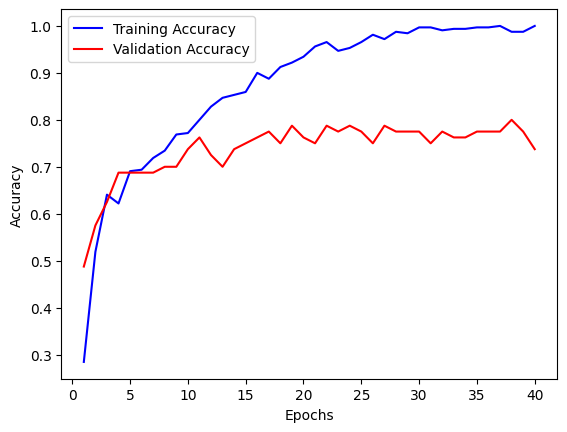

In [13]:
# Plot evolution of accuracies throughout the training
###
# Axis labels
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

# Training sample accuracy curve
plt.plot(np.arange(1 , 41, 1),
         training_history_lenet.history['accuracy'],
         label = 'Training Accuracy',
         color = 'blue')

# Test sample accuracy curve
plt.plot(np.arange(1 , 41, 1),
         training_history_lenet.history['val_accuracy'],
         label = 'Validation Accuracy',
         color = 'red')

# Legend display
plt.legend()

# Figure display
plt.show()

In [14]:
# Model results
###
# make predictions of labels on x_test
test_pred = lenet.predict(X_test)
print("Shape of predictions:", test_pred.shape)
# 2 Dimensional matrix of 10k x 10 dimension

# apply argmax on predictions to obtain vectors of integeres
# choose axis = 1 to perform argmax on columns
test_pred_class = test_pred.argmax(axis = 1)
print("Shape of predictions after argmax:", test_pred_class.shape)
# 1 Dimensional Vector of 10k x 1 dimension

y_test_class = y_test.argmax(axis = 1)

# show classification report
print(metrics.classification_report(y_test_class, test_pred_class))

# Measure time
model1_time = (time.time() - start_time)/60

# Modelling Time
print("Model 1: --- %s minutes ---" % model1_time)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Shape of predictions: (100, 4)
Shape of predictions after argmax: (100,)
              precision    recall  f1-score   support

           0       0.76      0.70      0.73        50
           1       0.53      0.47      0.50        17
           2       0.59      0.70      0.64        27
           3       0.86      1.00      0.92         6

    accuracy                           0.68       100
   macro avg       0.69      0.72      0.70       100
weighted avg       0.68      0.68      0.68       100

Model 1: --- 1.4041523814201355 minutes ---


[[35  7  7  1]
 [ 3  8  6  0]
 [ 8  0 19  0]
 [ 0  0  0  6]]


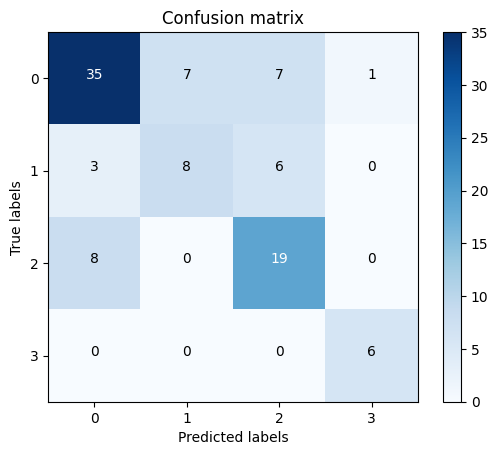

In [15]:
# Show confusion matrix
cnf_matrix = metrics.confusion_matrix(y_test_class, test_pred_class)
print(cnf_matrix)

# Display a confusion matrix as a colored table
classes = range(0, 4)

plt.figure()

plt.imshow(cnf_matrix, interpolation='nearest',cmap='Blues')
plt.title("Confusion matrix")
plt.colorbar()
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes)
plt.yticks(tick_marks, classes)

for i, j in itertools.product(range(cnf_matrix.shape[0]), range(cnf_matrix.shape[1])):
    plt.text(j, i, cnf_matrix[i, j],
             horizontalalignment="center",
             color="white" if cnf_matrix[i, j] > ( cnf_matrix.max() / 2) else "black")

plt.ylabel('True labels')
plt.xlabel('Predicted labels')
plt.show()
